In [1]:
import pandas as pd

In [2]:
df_uo = pd.read_csv('../data/raw/etl_users_orders_dirty_v3.csv')

In [3]:
df_o = df_uo[['user_id', 'order_id', 'order_date', 'category', 'amount', 'status']]
df_o = df_o.drop_duplicates(subset='order_id')
df_o['order_date'] = pd.to_datetime(df_o['order_date'], errors='coerce')
df_o['amount'] = pd.to_numeric(df_o['amount'], errors='coerce')
df_o = df_o[(df_o['amount'] > 0) | (df_o['amount'].isnull())]

In [4]:
df_res = df_o
df_res['year'] = df_res['order_date'].dt.year
df_res['month'] = df_res['order_date'].dt.month
df_res.head()

,user_id,order_id,order_date,category,amount,status,year,month
0,36531,141114,2025-06-22 16:00:00,Clothing,5048.14,returned,2025,6
1,36738,200584,2026-04-02 20:00:00,Books,100085.64,returned,2026,4
2,12748,133499,2026-06-24 22:00:00,Home,55017.65,pending,2026,6
3,20291,145053,2025-06-02 18:00:00,Home,49928.84,completed,2025,6
4,3380,143977,2025-12-19 18:00:00,Electronics,31371.82,completed,2025,12


<Axes: xlabel='year,month'>

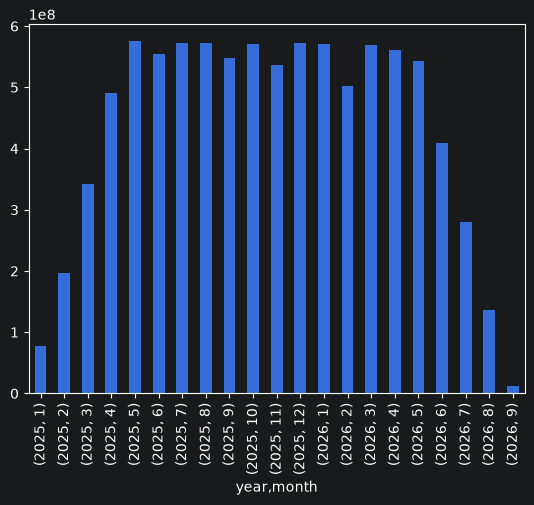

In [5]:
#Из графика видно, что где-то с 2025-05-01 по 2026-05-01 прибыль была +- одинаковой, вначале 2025 года и в конце 2026 наблюдается спад
df_res.groupby(['year', 'month']).amount.sum().plot(kind = 'bar')